# Telco Churn EDA

This notebook loads the raw Telco churn data, cleans `TotalCharges` explicitly, engineers a few features, and saves churn-rate plots for Phase 1.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from src.data_prep import clean_telco_data, load_telco_data, save_clean_data
from src.features import add_feature_columns, save_featured_data

sns.set_theme(style="whitegrid")
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"
DATA_DIR.mkdir(exist_ok=True)
RAW_PATH = BASE_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
EDA_DIR = DATA_DIR / "eda"
EDA_DIR.mkdir(exist_ok=True)

In [3]:
raw_df = load_telco_data(RAW_PATH)
clean_df, clean_report = clean_telco_data(raw_df)
featured_df = add_feature_columns(clean_df)

save_clean_data(clean_df, DATA_DIR / "telco_clean.csv")
save_featured_data(featured_df, DATA_DIR / "telco_features_phase1.csv")

clean_report

CleanReport(rows_before=7043, rows_after=7032, rows_dropped_zero_tenure_totalcharges=11, rows_dropped_unexpected_missing_totalcharges=0)

In [4]:
def churn_rate_table(frame, group_col):
    return (
        frame.groupby(group_col)["Churn"]
        .agg(churn_rate="mean", customers="size")
        .sort_values("churn_rate", ascending=False)
    )

contract_breakdown = churn_rate_table(featured_df, "Contract")
tenure_breakdown = churn_rate_table(featured_df, "tenure_bucket")
service_breakdown = churn_rate_table(featured_df, "total_service_count")
monthly_bins = pd.cut(featured_df["MonthlyCharges"], bins=[0, 35, 65, 90, 130], include_lowest=True)
monthly_breakdown = churn_rate_table(featured_df.assign(monthly_bin=monthly_bins), "monthly_bin")

print("Contract churn rate:")
display(contract_breakdown)
print("Tenure bucket churn rate:")
display(tenure_breakdown)
print("Monthly charges churn rate:")
display(monthly_breakdown)
print("Service count churn rate:")
display(service_breakdown)

Contract churn rate:


,churn_rate,customers
Contract,,
Month-to-month,0.427097,3875
One year,0.112772,1472
Two year,0.028487,1685


Tenure bucket churn rate:


,churn_rate,customers
tenure_bucket,,
0-6,0.533333,1470
7-12,0.358865,705
13-24,0.287109,1024
25-48,0.203890,1594
49-72,0.095132,2239


Monthly charges churn rate:


,churn_rate,customers
monthly_bin,,
"(65.0, 90.0]",0.363299,2158
"(90.0, 130.0]",0.327775,1739
"(35.0, 65.0]",0.231863,1406
"(-0.001, 35.0]",0.109312,1729


Service count churn rate:


,churn_rate,customers
total_service_count,,
3,0.449173,846
4,0.364767,965
5,0.313789,921
2,0.310385,857
6,0.256071,906
7,0.225519,674
8,0.124051,395
1,0.109524,1260
9,0.052885,208


WindowsPath('c:/Users/Mega Pc/Desktop/stage/data/eda/phase1_churn_breakdowns.png')

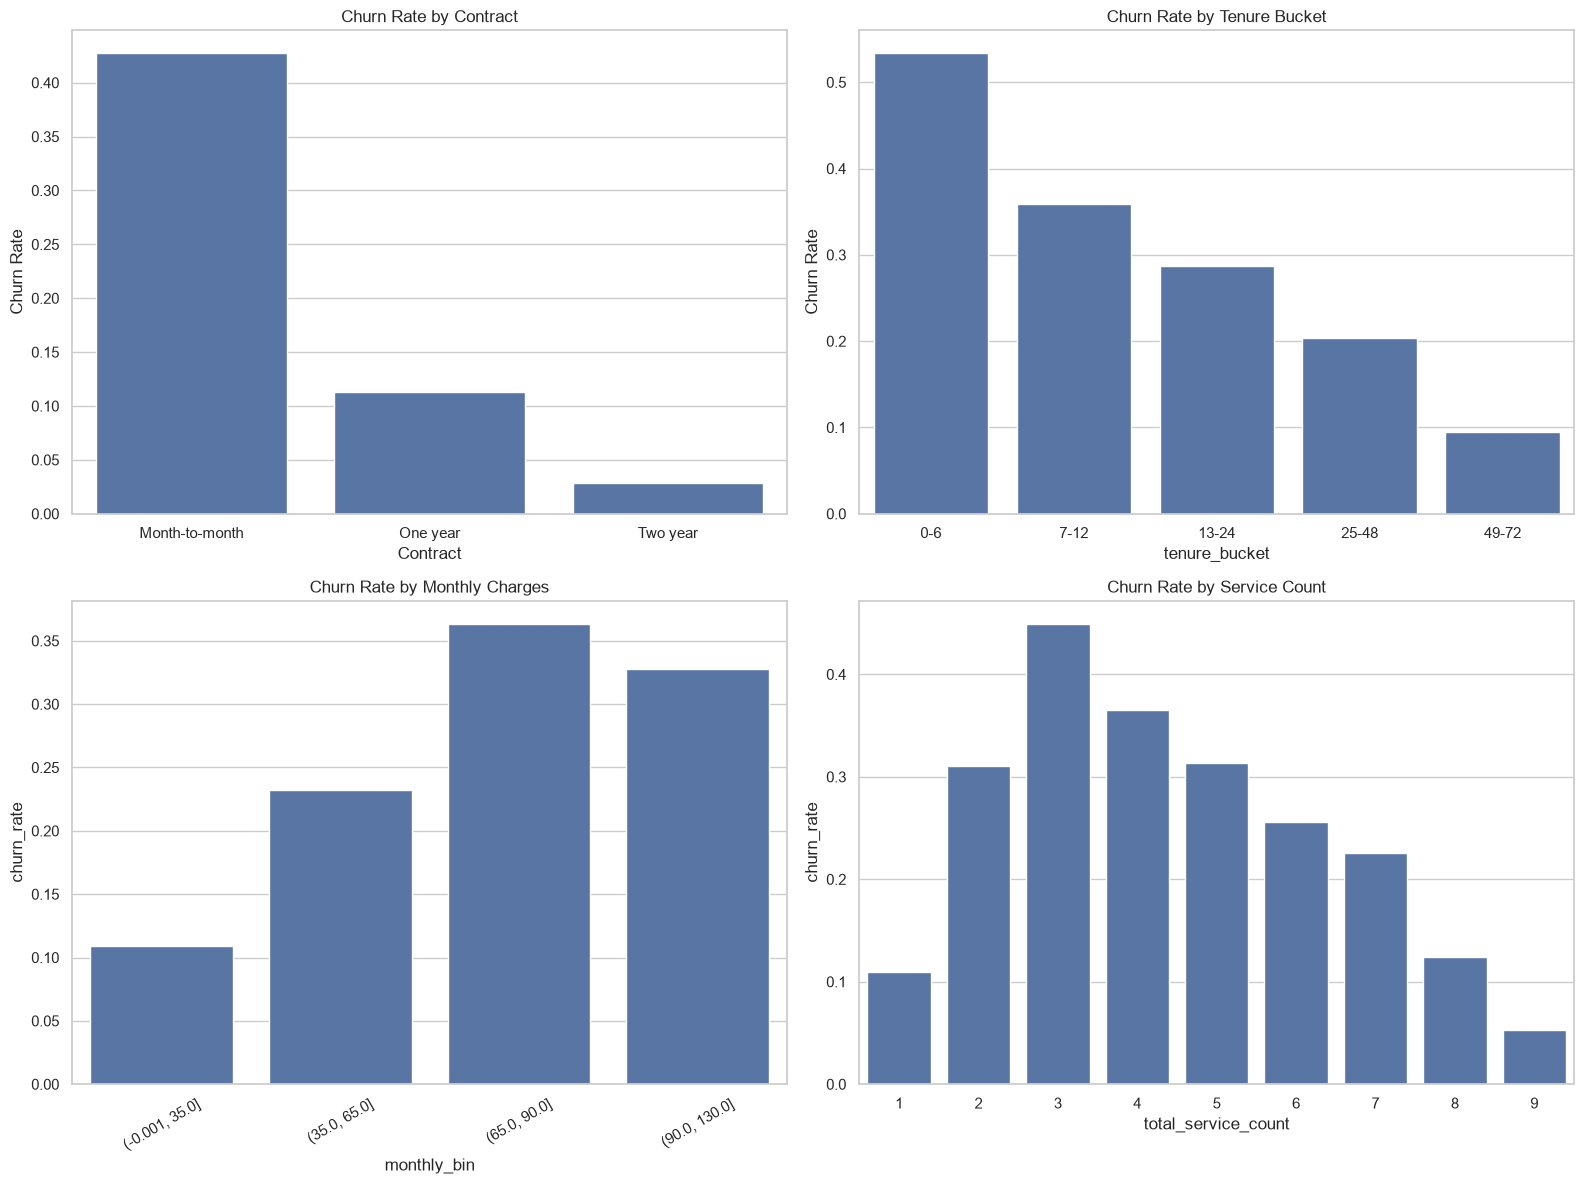

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=contract_breakdown.reset_index(), x="Contract", y="churn_rate", ax=axes[0, 0])
axes[0, 0].set_title("Churn Rate by Contract")
axes[0, 0].set_ylabel("Churn Rate")

sns.barplot(data=tenure_breakdown.reset_index(), x="tenure_bucket", y="churn_rate", ax=axes[0, 1])
axes[0, 1].set_title("Churn Rate by Tenure Bucket")
axes[0, 1].set_ylabel("Churn Rate")

sns.barplot(data=monthly_breakdown.reset_index(), x="monthly_bin", y="churn_rate", ax=axes[1, 0])
axes[1, 0].set_title("Churn Rate by Monthly Charges")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.barplot(data=service_breakdown.reset_index(), x="total_service_count", y="churn_rate", ax=axes[1, 1])
axes[1, 1].set_title("Churn Rate by Service Count")

plt.tight_layout()
plot_path = EDA_DIR / "phase1_churn_breakdowns.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plot_path